In [16]:
import sys
print(sys.executable)

c:\Users\saumy\Desktop\project\credit-card-fraud-ai\.venv\Scripts\python.exe


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything is working 🎉")

Everything is working 🎉


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [19]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [20]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
df.shape


(284807, 31)

In [22]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Dataset Overview

- Total transactions: 284,807
- Total columns: 31
- Target column: `Class`
- Features: `Time`, `V1`–`V28`, `Amount`
- No missing values are present.
- Most features are `float64` because they were transformed using PCA.
- `Class` is an `int64` binary label (0 = legitimate, 1 = fraud).
- Dataset size in memory: ~67.4 MB.

In [23]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [24]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

## Class Distribution

The dataset is highly imbalanced.

- Legitimate transactions (Class = 0): 284,315 (99.83%)
- Fraudulent transactions (Class = 1): 492 (0.17%)

This imbalance means that accuracy alone is not an appropriate evaluation metric. Metrics such as Precision, Recall, F1-score, and ROC-AUC will be more suitable for evaluating fraud detection models.

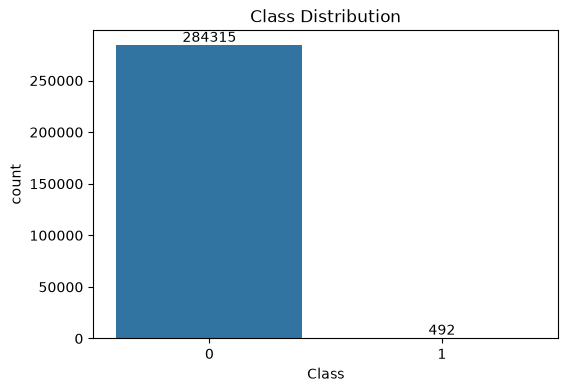

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("../data/raw/creditcard.csv")
plt.figure(figsize=(6,4))
ax = sns.countplot(x="Class", data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution")
plt.show()

In [26]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

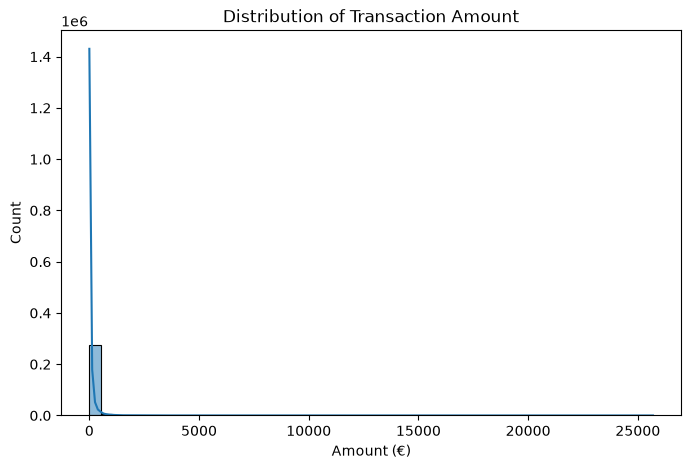

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount (€)")
plt.show()

In [28]:
df.duplicated().sum()

np.int64(1081)

In [29]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1081


## Removing Duplicate Records

The dataset contains duplicate transactions that can bias the machine learning model. These duplicate records are removed to ensure the model learns from unique observations only.

In [30]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


In [31]:
df.duplicated().sum()

np.int64(0)

### Observation

A total of **1,081 duplicate transactions** were found and removed from the dataset.

Removing duplicate observations prevents the model from learning repeated patterns and helps produce more reliable evaluation metrics.

## Time Feature Analysis

The `Time` feature represents the number of seconds elapsed between each transaction and the first transaction in the dataset.

In this section, we analyze the distribution of transaction times to understand how transactions are spread throughout the observation period.

In [32]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

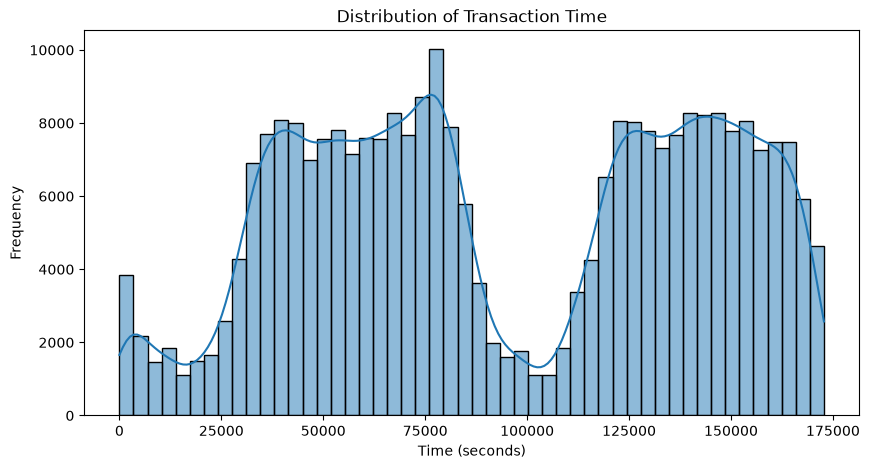

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50, kde=True)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.show()

### Observation

- The `Time` feature ranges from the beginning to the end of the data collection period.
- Transactions are distributed across the entire observation window.
- No obvious gaps are visible, indicating continuous transaction activity.